## Minimum Spectral Entropy Demonstration (Phase and Delay)

This notebook demonstrates a method for controlling stochastic delay and phase noise in $H(\nu,t)e^{i(\phi_t+\epsilon_t \nu)}$, where $H(\nu,t)$ is the dynamic frequency response determined by dynamic cyclic spectroscopy, $\phi_t$ and $\epsilon_t$ are the unknown degenerate phase and delay at time $t$.

The method is based on minimizing the spectral entropy in $h(\tau,\omega)$ by varying $\phi_t$ and $\epsilon_t$.

In [1]:
from scipy.fft import rfft, fft, fftshift, ifft, fftn, ifftn
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np
import psrchive

def freq2time(hf, axis=0):
    return ifft(hf, axis=axis, norm="ortho")

def time2freq(ht, axis=0):
    return fft(ht, axis=axis, norm="ortho")

## Spectral Entropy

Defined as $$U = - \sum_j \sum_k p_{jk} \log_2 p_{jk},$$
where $p_{jk}$ is the fractional power spectral density,

\begin{equation}
p_{jk} = P_{jk} \Sigma_P^{-1},
\end{equation}

$P_{jk} = | h^\prime(\tau_j;\omega_k) |^2$ is the power at a
given delay and Doppler shift, and

\begin{equation}
\Sigma_P =  \sum_j \sum_k P_{jk}
\end{equation}

is the total power summed over all delays and Doppler shifts, which remains constant
as the values of $\phi_t$ and $\epsilon_t$ are varied.

See https://www.overleaf.com/read/mjqhtxmtpmmd#19ec75 for derivation of the partial derivatives $dU/d\phi_t$ and $dU/d\epsilon_t$.

In [2]:
def spectral_entropy_grad(alpha, h_time_freq):
    """
    Calculates the total spectral entropy of the time-to-Doppler forward Fourier transform
    and freq-to-delay inverse Fourier transform of the input h_time_freq after mupltiplying each row/time (except the first) by phi
    and shifting each row/time by delay epsilon

    Args:
    alpha: A 1D array of (Ntime - 1) real-valued phase shifts, in radians,
        and (Ntime - 1) real-valued delays, in radians per cycle, to be applied to each row except the first
    h_time_freq: the dynamic frequency response, a 2D array of Ntime * Nfreq complex-values

    Returns:
    The spectral entropy and its gradient with respect to the phase shifts and delays
    """

    Ntime, Nchan = h_time_freq.shape
    
    phs = np.zeros(Ntime)
    eps = np.zeros(Ntime)

    phs[1:] = alpha[0:Ntime-1]
    eps[1:] = alpha[Ntime-1:]

    nus = np.fft.fftfreq(Nchan)
    h_time_freq_prime = h_time_freq * np.exp(1j * np.outer(eps, nus))
    dh_time_freq_prime_deps_oni = np.multiply(h_time_freq_prime, nus[np.newaxis, :])

    h_time_delay_prime = ifft(h_time_freq_prime, axis=1, norm="ortho")
    dh_time_delay_prime_deps_oni = ifft(dh_time_freq_prime_deps_oni, axis=1, norm="ortho")

    phasors = np.exp(1.j * phs)
    h_time_delay_prime = np.multiply(h_time_delay_prime, phasors[:, np.newaxis])
    dh_time_delay_prime_deps_oni = np.multiply(dh_time_delay_prime_deps_oni, phasors[:, np.newaxis])
    
    h_doppler_delay_prime = fft(h_time_delay_prime, axis=0, norm="ortho")
    
    power_spectrum = np.abs(h_doppler_delay_prime)**2
    
    total_power = np.sum(power_spectrum)
    power_spectrum /= total_power
    log_power_spectrum = np.log2(power_spectrum + 1e-16)
    entropy = -np.sum(power_spectrum * log_power_spectrum)

    weighted_ifft = fft((1.+log_power_spectrum)*np.conj(h_doppler_delay_prime), axis=0, norm="ortho")

    # partial derivatives with respect to phi_l
    gradient_phs = 2.0/total_power * np.sum( np.imag( weighted_ifft*h_time_delay_prime ), axis=1)
    grad_phs_power = np.sum(gradient_phs**2)

    # partial derivatives with respect to epsilon_l
    gradient_eps = 2.0/total_power * np.sum( np.imag( weighted_ifft*dh_time_delay_prime_deps_oni ), axis=1)    
    grad_eps_power = np.sum(gradient_eps**2)

    rms = np.sqrt(np.sum(phs**2) / (Ntime-1))
    print (f"rms={rms:.4g} rad; S={entropy} grad power phs={grad_phs_power:.4} eps={grad_eps_power:.4}")

    return entropy, np.concatenate((gradient_phs[1:],gradient_eps[1:]))

def spectral_entropy(h_time_freq):
    """
    Calculates the total spectral entropy of the time-to-Doppler forward Fourier transform 
    of the input h_time_delay

    Args:
    h_time_freq: the dynamic frequency response, a 2D array of Ntime * Nfreq complex-values

    Returns:
    The spectral entropy
    """
    nsub, nchan = h_time_freq.shape
    alpha = np.zeros(2*(nsub-1))
    entropy, grad = spectral_entropy_grad(alpha,h_time_freq)
    return entropy

## Minimize the spectral entropy using BFGS

In [3]:
from scipy.optimize import minimize

def circular(x):
    x[:] = np.fmod(x, 2.0*np.pi)

def minimize_spectral_entropy(h_time_freq, guess_phi = None, guess_eps = None):

    Ntime, Nchan = h_time_freq.shape
    initial_guess = np.zeros(2*(Ntime - 1))

    if guess_phi is not None:
        print("Setting first guess for phi")
        initial_guess[0:Ntime-1] = guess_phi

    if guess_eps is not None:
        print("Setting first guess for epsilon")
        initial_guess[Ntime-1:] = guess_eps
        
    options = {"maxiter": 1000, "disp": True}

    result = minimize(
        spectral_entropy_grad,
        initial_guess,
        args=(h_time_freq,),
        method="BFGS",
        jac=True,
        callback=circular,
        options=options,
    )

    alpha = result.x
    phs = np.zeros(Ntime)
    eps = np.zeros(Ntime)

    phs[1:] = alpha[0:Ntime-1]
    eps[1:] = alpha[Ntime-1:]

    nus = np.fft.fftfreq(Nchan)
    h_time_freq_prime = h_time_freq * np.exp(1j * np.outer(eps, nus))

    phasors = np.exp(1.j * phs)
    h_time_freq[:,:] = np.multiply(h_time_freq_prime, phasors[:, np.newaxis])

### Difference between two spectra

Details of chi-squared function


In [4]:

def spectral_distance(alpha, z, w):
    """
    Calculates the magnitude of the difference between the two spectra in the two halve of two_spectra
    after mupltiplying the second one by an amplitude, phase, and phase gradient

    Args:
    alpha: A 1D array of 3 values: amplitude, phase, and slope
    two_spectra: the complex-valued spectra to be aligned

    Returns:
    The distance and its gradient with respect to the 3 parameters in alpha
    """

    Nchan = z.size
    phase = alpha[0]
    slope = alpha[1]
    amplitude = 1
    print(f"{amplitude=} {phase=} {slope=}")

    nus = np.fft.fftfreq(Nchan)
    wprime = amplitude * np.exp(1j * phase) * w * np.exp(1j * slope * nus)
    delta = z - wprime

    diff = np.sum(np.abs(delta)**2)

    del_amplitude = wprime / amplitude
    del_phase = 1j * wprime
    del_slope = 1j * nus * wprime

    ddiff_damp = -2 * np.sum ( np.real( np.conj(delta) * del_amplitude ) )
    ddiff_dphs = -2 * np.sum ( np.real( np.conj(delta) * del_phase ) )
    ddiff_dslo = -2 * np.sum ( np.real( np.conj(delta) * del_slope ) )

    print(f"{diff=} del_a={ddiff_damp} del_phi={ddiff_dphs} del_eps={ddiff_dslo}")
    return diff, [ddiff_dphs, ddiff_dslo]

def minimize_difference(z, w):

    Nchan = z.size
    initial_guess = np.zeros(2)

    ccf = fft( np.conj(w) * z )
    ccf_power = np.abs(ccf)**2
    imax = np.argmax(ccf_power)
    ph_max = np.angle(ccf[imax])

    print(f"{imax=} {ph_max=} {Nchan=}")
    
    initial_guess[0] = ph_max

    if imax < Nchan // 2:
        slope = imax
    else:
        slope = imax - Nchan

    initial_guess[1] = slope * 2.0 * np.pi

    options = {"maxiter": 1000, "disp": True, "gtol": 1e-12}
    
    result = minimize(
        spectral_distance,
        initial_guess,
        args=(z,w),
        method="BFGS",
        jac=True,
        # callback=circular,
        options=options,
    )

    alpha = result.x

    phase = alpha[0]
    slope = alpha[1]
    amplitude = 1
    
    nus = np.fft.fftfreq(Nchan)
    w[:] = amplitude * np.exp(1j * phase) * w * np.exp(1j * slope * nus)

## Simulated scattering screen

Load a simulated dynamic response, $H(\nu,t)$ that was generated using 

    dyn_resp_sim input.ar -w1
    
This generates a single scintillation arc with a Gaussian width of one pixel.  The following code also plots $h(\tau,\omega)$ and reports the original entropy.

**Note the original spectral entropy of 7.656.**

In [5]:
# filename = "test/dyn_resp_sim.fits"
filename = "../test_data/cyclbfgsb_best.fits"
ar = psrchive.Archive_load(filename)
ext = ar.get_dynamic_response()
data = ext.get_data()
nchan = ext.get_nchan()
ntime = ext.get_ntime()
h_time_freq = np.reshape(data, (ntime, nchan))

start_time = ext.get_minimum_epoch ()
end_time = ext.get_maximum_epoch ()
dT = (end_time-start_time).in_seconds() / ntime
if dT == 0:
    dT = 1

print(f"start_time={start_time.printdays(13)} end_time={end_time.printdays(13)}")

bw = ext.get_bandwidth()
cfreq = ext.get_centre_frequency()

print(f"delta-T={dT} centre frequency={cfreq} bandwidth={bw}")
print(f"\nInitial Spectral Entropy: {spectral_entropy(h_time_freq)}\n")


start_time=53873.3225348010965 end_time=53873.3636546577036
delta-T=14.990530003604915 centre frequency=428.0 bandwidth=3.55552
rms=0 rad; S=14.224021616086816 grad power phs=0.0001964 eps=7.42e-05

Initial Spectral Entropy: 14.224021616086816



rms=0 rad; S=14.224021616086816 grad power phs=0.0001964 eps=7.42e-05
Spectral Entropy: 14.224021616086816


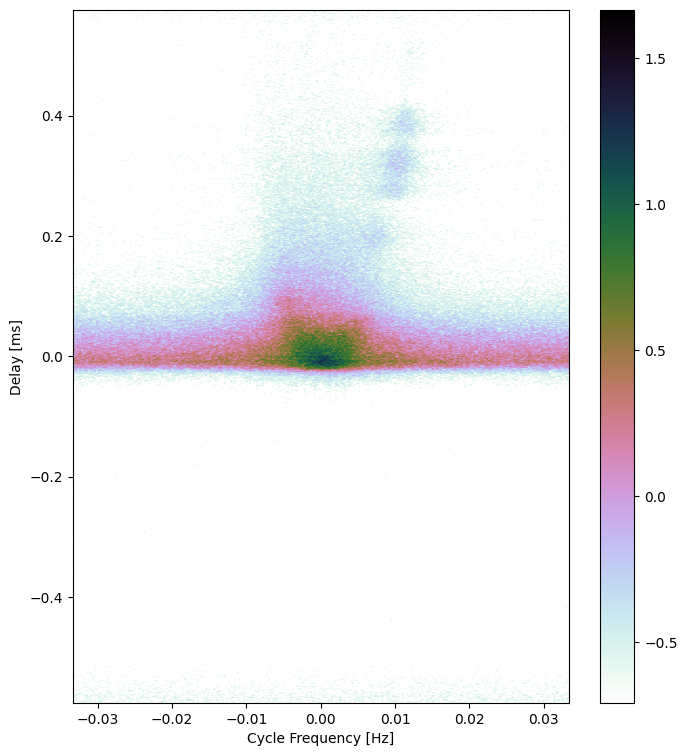

In [6]:
def plot_Doppler_vs_delay (h_time_freq, dT, cfreq, bw):

    print(f"Spectral Entropy: {spectral_entropy(h_time_freq)}")

    h_time_delay = freq2time(h_time_freq, axis=1)
    h_doppler_delay = time2freq(h_time_delay, axis=0)

    ntime, ntap = h_time_delay.shape

    delta_delay_mus = np.abs(1.0 / bw)
    max_delay_ms = delta_delay_mus * ntap * 0.5e-3
    max_Doppler_Hz = .5 / dT
    
    extent=[-max_Doppler_Hz, max_Doppler_Hz, -max_delay_ms, max_delay_ms]
    
    plotthis = np.log10(np.abs(fftshift(h_doppler_delay)) + 1e-2)
    plotmed = np.median(plotthis)
    fig, ax = plt.subplots(figsize=(8, 9))

    ax.set_xlabel("Cycle Frequency [Hz]")
    ax.set_ylabel("Delay [ms]")
    img = ax.imshow(plotthis.T, aspect="auto", origin="lower", cmap="cubehelix_r", vmin=plotmed, extent=extent)

    fig.colorbar(img)
    
plot_Doppler_vs_delay(h_time_freq, dT, cfreq, bw)

## Scramble the phases

Multiply each row of the dynamic frequency response by a random phase.

In [7]:
max_phase = np.pi*4
phases = np.random.uniform(-max_phase,max_phase,ntime)
phases[0] = 0
phasors = np.exp( 1j * phases)
h_time_freq = np.multiply(h_time_freq, phasors[:, np.newaxis])

## Scramble the delays

Multiply each row of the dynamic frequency response by a phase slope for a random delay.

In [8]:
eps = np.random.uniform(-max_phase,max_phase,ntime)
eps[0] = 0
nus = np.fft.fftfreq(nchan)
h_time_freq = h_time_freq * np.exp(1j * np.outer(eps, nus))

## Unaligned Wavefield

A Fourier transform along the delay axis yields $H(\nu,t)$, which is then passed to the plot function, which computes and plots the 2D FFT, $h(\tau,\omega)$.  This is expected to look like white Doppler noise because of the large time shifts $\epsilon_t$ that are clearly visible in the above plot.

rms=0 rad; S=15.715811727197922 grad power phs=7.098e-05 eps=5.31e-06
Spectral Entropy: 15.715811727197922


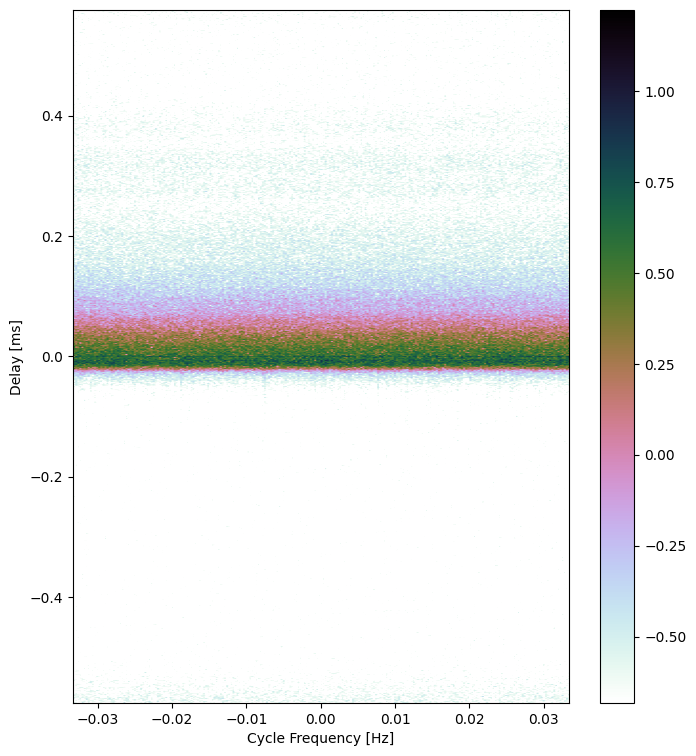

In [9]:
plot_Doppler_vs_delay(h_time_freq, dT, cfreq, bw)

## Coarse alignment using the cross-correlation function.

Each impulse response in $h(\tau,t)$ is aligned to its neighbour and multiplied by a phase term, based on the cross-correlation between them.

In [10]:
def align_to_neighbour(subset):
    nt, ntau = subset.shape
    x = subset[0]
    for idx in range(1,nt):
        y = subset[idx]
        minimize_difference(x,y)
        x = y
        subset[idx,:] = y

In [11]:
coarse_h_time_freq = np.copy(h_time_freq)
align_to_neighbour(coarse_h_time_freq)

imax=0 ph_max=2.5144014900016867 Nchan=4096
amplitude=1 phase=2.5144014900016867 slope=0.0
diff=1008.3291849982065 del_a=1008.3291849982054 del_phi=7.958078640513122e-13 del_eps=-297.8492252640584
amplitude=1 phase=2.514401490001684 slope=1.0100000000000005
diff=874.3789479167089 del_a=874.3789479167077 del_phi=663.1336410022226 del_eps=35.107485790207264
amplitude=1 phase=2.0582800574813933 slope=1.9183529242814614
diff=1229.9122123282455 del_a=1229.912212328245 del_phi=-2039.532030201753 del_eps=33.060985836508905
amplitude=1 phase=2.418086314506551 slope=1.201808946205996
diff=845.4468105530207 del_a=845.4468105530201 del_phi=80.77390888352096 del_eps=37.02244428495128
amplitude=1 phase=2.416561659005065 slope=1.0924693523108475
diff=843.3995267047696 del_a=843.3995267047688 del_phi=-1.3568851186661828 del_eps=-0.6846815069830108
amplitude=1 phase=2.4165672489294137 slope=1.0944974166024324
diff=843.3988287247931 del_a=843.3988287247921 del_phi=-0.0001340575007442446 del_eps=0.00010

/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desire

diff=3113.604210849615 del_a=3113.6042108496176 del_phi=-205.02613615618156 del_eps=-824.1845553874209
amplitude=1 phase=3.9864372307608056 slope=-9.72793131940556
diff=11442.003280825236 del_a=11442.00328082524 del_phi=4987.622816515108 del_eps=-57.33244918742275
amplitude=1 phase=1.8816667173278432 slope=-11.45217829249726
diff=3042.678938505541 del_a=3042.678938505543 del_phi=431.71003760332405 del_eps=-807.422542931296
amplitude=1 phase=1.8795540257461099 slope=-11.275867906790147
diff=2904.8312043755286 del_a=2904.831204375532 del_phi=404.832706994325 del_eps=-745.5863166812503
amplitude=1 phase=1.8711032594191768 slope=-10.570626363961692
diff=2472.6311808615656 del_a=2472.6311808615674 del_phi=288.4875144963761 del_eps=-463.2970920169726
amplitude=1 phase=1.8378853925598724 slope=-9.388759917046439
diff=2241.1779471106315 del_a=2241.177947110634 del_phi=-40.83923110780506 del_eps=87.26476594880103
amplitude=1 phase=1.840895371563963 slope=-9.576750826563924
diff=2233.14990242186

/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desire

diff=3010.4692627099384 del_a=3010.46926270994 del_phi=2.2737367544323206e-13 del_eps=1104.7680071307038
amplitude=1 phase=-0.28515522851991576 slope=-19.85955592153876
diff=2067.987786836779 del_a=2067.9877868367794 del_phi=-62.423763381026674 del_eps=741.8336822646817
amplitude=1 phase=9.326330118180152 slope=-21.617129789391225
diff=14830.49480760589 del_a=14830.494807605894 del_phi=-1132.0837138664328 del_eps=63.36389862326319
amplitude=1 phase=-0.10932066472927149 slope=-19.891709352900936
diff=2127.917308455145 del_a=2127.9173084551458 del_phi=1012.2372085298654 del_eps=726.652514641115
amplitude=1 phase=-0.25285717543924907 slope=-19.865462002860163
diff=2064.783688390542 del_a=2064.783688390544 del_phi=135.1891101355352 del_eps=740.754489820858
amplitude=1 phase=-0.2529046672029129 slope=-19.87419074980801
diff=2058.327225221352 del_a=2058.3272252213533 del_phi=134.63367059875964 del_eps=737.132568631451
amplitude=1 phase=-0.253094634257568 slope=-19.909105737599415
diff=2032.8

...

/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desire

diff=1574.4299077700184 del_a=1574.42990777002 del_phi=-1.4097167877480388e-11 del_eps=2.5650592760939617e-12
amplitude=1 phase=-0.09479394996119057 slope=-105.1803214166355
diff=1574.4299077700184 del_a=1574.4299077700202 del_phi=-1.6399326341343112e-11 del_eps=2.6503244043851737e-12
amplitude=1 phase=-0.09479394996119074 slope=-105.1803214166355
diff=1574.4299077700184 del_a=1574.4299077700202 del_phi=-1.750777300912887e-11 del_eps=2.6219026949547697e-12
amplitude=1 phase=-0.09479394996119082 slope=-105.1803214166355
diff=1574.4299077700184 del_a=1574.4299077700207 del_phi=-1.807620719773695e-11 del_eps=2.6574298317427747e-12
amplitude=1 phase=-0.09479394996119087 slope=-105.1803214166355
diff=1574.4299077700184 del_a=1574.4299077700207 del_phi=-1.8332002582610585e-11 del_eps=2.6858515411731787e-12
amplitude=1 phase=-0.09479394996119088 slope=-105.1803214166355
diff=1574.4299077700184 del_a=1574.4299077700207 del_phi=-1.8332002582610585e-11 del_eps=2.6858515411731787e-12
amplitude=1 

/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desire

diff=1160.1947057406337 del_a=1160.194705740631 del_phi=-6.5226348766600495e-09 del_eps=-9.949361334804507e-10
amplitude=1 phase=0.6115588162928762 slope=-110.1221351994274
diff=1160.1947057406337 del_a=1160.194705740632 del_phi=-6.471348346082095e-09 del_eps=-9.876868212188583e-10
amplitude=1 phase=0.611558816292881 slope=-110.12213519942739
diff=1160.1947057406337 del_a=1160.1947057406317 del_phi=-6.4375322850196426e-09 del_eps=-9.804375089572659e-10
amplitude=1 phase=0.6115588162928827 slope=-110.12213519942739
diff=1160.1947057406337 del_a=1160.194705740632 del_phi=-6.426278620352832e-09 del_eps=-9.803997613744286e-10
amplitude=1 phase=0.6115588162928832 slope=-110.12213519942739
diff=1160.1947057406337 del_a=1160.1947057406317 del_phi=-6.4223621976111644e-09 del_eps=-9.80398429106799e-10
amplitude=1 phase=0.6115588162928834 slope=-110.12213519942739
diff=1160.194705740634 del_a=1160.194705740632 del_phi=-6.420634246495638e-09 del_eps=-9.803922118578612e-10
amplitude=1 phase=0.6115

/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desire

In [12]:
align_to_neighbour(coarse_h_time_freq)

imax=0 ph_max=7.715980805525768e-14 Nchan=4096
amplitude=1 phase=7.715980805525768e-14 slope=0.0
diff=843.3988287247693 del_a=843.3988287247686 del_phi=-2.042810365310288e-14 del_eps=-2.566047374585878e-11
amplitude=1 phase=9.758791170836056e-14 slope=2.566047374585878e-11
diff=843.3988287247693 del_a=843.3988287247689 del_phi=1.6796937618579477e-08 del_eps=8.606059975768687e-09
amplitude=1 phase=7.722044305217964e-14 slope=7.616579458465094e-14
diff=843.3988287247691 del_a=843.3988287247686 del_phi=4.983746748621343e-11 del_eps=-3.275157922644212e-14
amplitude=1 phase=-4.966978301181856e-11 slope=9.685731398599134e-11
diff=843.3988287247693 del_a=843.3988287247687 del_phi=-3.0273580131634503e-07 del_eps=2.328046644350934e-10
amplitude=1 phase=7.722026200053726e-14 slope=7.616614681462691e-14
diff=843.3988287247691 del_a=843.3988287247686 del_phi=4.983746748621343e-11 del_eps=-3.275157922644212e-14
amplitude=1 phase=7.722008094889619e-14 slope=7.616649904460033e-14
diff=843.39882872476

/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desire

diff=261.3924114938843 del_a=261.39241149388266 del_phi=3.785860513971784e-13 del_eps=-5.681015102787512e-10
amplitude=1 phase=-3.074034704548077e-12 slope=5.383003360271617e-16
diff=261.3924114938843 del_a=261.39241149388266 del_phi=3.785860513971784e-13 del_eps=-5.681015102787512e-10
amplitude=1 phase=-3.074041171628444e-12 slope=2.5913739244155623e-13
diff=261.39241149388437 del_a=261.3924114938827 del_phi=1.6888934695202806e-10 del_eps=-4.950452825447371e-10
amplitude=1 phase=-3.07403470454808e-12 slope=5.38300447417751e-16
diff=261.3924114938843 del_a=261.39241149388266 del_phi=3.785860513971784e-13 del_eps=-5.681015102787512e-10
amplitude=1 phase=-3.074034704548083e-12 slope=5.383005588083403e-16
diff=261.3924114938843 del_a=261.39241149388266 del_phi=3.785860513971784e-13 del_eps=-5.681015102787512e-10
amplitude=1 phase=-3.0740379380882633e-12 slope=1.298378465001823e-13
diff=261.39241149388437 del_a=261.39241149388266 del_phi=8.462985867652151e-11 del_eps=-5.315796136606821e-10

/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desire

diff=2533.255764962917 del_a=2533.25576496292 del_phi=-5.522911266098163e-07 del_eps=4.246148357367474e-07
amplitude=1 phase=2.2972068943546167 slope=62.448809676539895
diff=2533.255764962917 del_a=2533.2557649629193 del_phi=-6.193808133048151e-07 del_eps=4.7619424137224087e-07
amplitude=1 phase=2.29720689435169 slope=62.44880967657399
diff=2533.255764962917 del_a=2533.2557649629193 del_phi=-6.435839736695925e-07 del_eps=4.948016680828005e-07
amplitude=1 phase=2.2972068943503787 slope=62.44880967658926
diff=2533.255764962917 del_a=2533.255764962919 del_phi=-6.544291721866102e-07 del_eps=5.031397449783981e-07
amplitude=1 phase=2.2972068943498125 slope=62.448809676595864
diff=2533.255764962917 del_a=2533.2557649629202 del_phi=-6.591129704247578e-07 del_eps=5.067423991533815e-07
amplitude=1 phase=2.297206894349566 slope=62.44880967659873
diff=2533.255764962917 del_a=2533.2557649629193 del_phi=-6.61149499592284e-07 del_eps=5.083053693510919e-07
amplitude=1 phase=2.2972068943494595 slope=62

...

/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desire

diff=2759.0069264177228 del_a=2759.0069264177237 del_phi=6.821210263296962e-13 del_eps=-280.44836275134685
amplitude=1 phase=-3.0148434565941855 slope=-17.839555921538757
diff=2705.910314948788 del_a=2705.9103149487883 del_phi=85.09744112463773 del_eps=174.74551862289877
amplitude=1 phase=-5.011347798074242 slope=-17.481078886015368
diff=10317.32374440741 del_a=10317.32374440741 del_phi=-4960.373538254778 del_eps=-203.6046015090966
amplitude=1 phase=-3.0229640104357576 slope=-17.838097857057026
diff=2705.654467929675 del_a=2705.6544679296753 del_phi=40.664544314543605 del_eps=174.73164605448426
amplitude=1 phase=-3.0229757279555494 slope=-17.84105287123256
diff=2705.1395946786934 del_a=2705.1395946786943 del_phi=40.35802763135155 del_eps=173.42132049632306
amplitude=1 phase=-3.023022598034717 slope=-17.852872927934694
diff=2703.11887283567 del_a=2703.118872835671 del_phi=39.130859276471654 del_eps=168.17665929230972
amplitude=1 phase=-3.0232100783513864 slope=-17.90015315474323
diff=26

/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desire

diff=1595.691135063903 del_a=1595.6911350639043 del_phi=-43.59856205927417 del_eps=147.86519686870832
amplitude=1 phase=-3.024913647293633 slope=-18.186317016848196
diff=1574.8644849513544 del_a=1574.8644849513553 del_phi=-8.658144221726403 del_eps=21.198181844746912
amplitude=1 phase=-3.0244866300265554 slope=-18.22736827454976
diff=1574.4299295457386 del_a=1574.42992954574 del_phi=-0.2727800837200789 del_eps=-0.12351808798889152
amplitude=1 phase=-3.024439896765206 slope=-18.227117545645143
diff=1574.4299077706457 del_a=1574.4299077706473 del_phi=0.002787968298719079 del_eps=0.00014704727405501217
amplitude=1 phase=-3.0244403272634326 slope=-18.227117938062094
diff=1574.4299077700184 del_a=1574.429907770019 del_phi=-8.14892368339315e-06 del_eps=1.5232948271659552e-06
amplitude=1 phase=-3.0244403260850747 slope=-18.227117940704243
diff=1574.4299077700184 del_a=1574.42990777002 del_phi=4.007290499430383e-09 del_eps=-4.396078168156237e-09
         Current function value: 1574.429908
   

/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desire

## Coarsely-aligned Wavefield

This still looks like white Doppler noise because of the remaining fractional time shifts $\epsilon_t$.

rms=0 rad; S=14.16137398325469 grad power phs=0.0002319 eps=1.691e-05
Spectral Entropy: 14.16137398325469


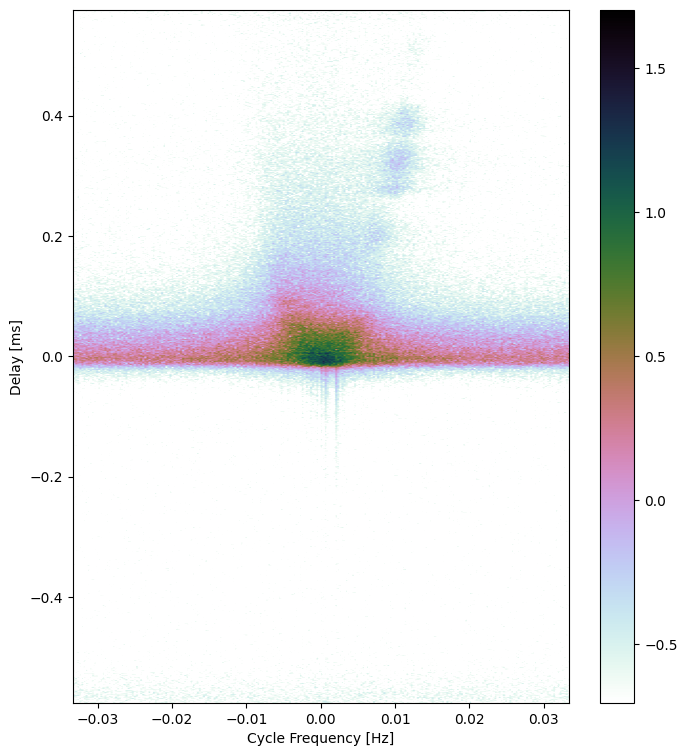

In [13]:
plot_Doppler_vs_delay(coarse_h_time_freq, dT, cfreq, bw)

## Perform fine alignment by minimizing the spectral entropy

In [14]:
first_guess_phi = -phases[1:]
first_guess_eps = -eps[1:]
# minimize_spectral_entropy(h_time_freq, first_guess_phi, first_guess_eps)
minimize_spectral_entropy(coarse_h_time_freq)

rms=0 rad; S=14.16137398325469 grad power phs=0.0002319 eps=1.691e-05
rms=0.0009899 rad; S=14.161127459317926 grad power phs=0.0002254 eps=1.689e-05
rms=0.00495 rad; S=14.160174129387794 grad power phs=0.0002011 eps=1.682e-05
rms=0.02079 rad; S=14.156888504322499 grad power phs=0.0001263 eps=1.655e-05
rms=0.07065 rad; S=14.152011027809923 grad power phs=0.0001316 eps=1.569e-05
rms=0.07509 rad; S=14.151827573815842 grad power phs=0.0001447 eps=1.557e-05
rms=0.08026 rad; S=14.151485951018422 grad power phs=0.0001559 eps=1.538e-05
rms=0.08761 rad; S=14.150846986367608 grad power phs=0.0001657 eps=1.505e-05
rms=0.09939 rad; S=14.149679154550991 grad power phs=0.0001723 eps=1.446e-05
rms=0.1199 rad; S=14.147687246294463 grad power phs=0.0001727 eps=1.337e-05
rms=0.1577 rad; S=14.144972361440324 grad power phs=0.0001749 eps=1.146e-05
rms=0.1746 rad; S=14.143677294320259 grad power phs=0.0001694 eps=1.054e-05
rms=0.1777 rad; S=14.142684723430424 grad power phs=0.0001641 eps=1.01e-05
rms=0.170

/home/willem/.local/lib/python3.9/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


## Finely-aligned Wavefield

After fine alignment, an arc appears!  It's at a funny delay and Doppler shift, but it's a start!  The offeset in cycle frequency $\Delta\omega$ could be fixed by a applying a phase gradient along the time axis; i.e. $h^\prime(\tau,t)= h(\tau,t)\exp(i2\pi t\Delta\omega)$

rms=0 rad; S=14.089260479966887 grad power phs=3.421e-07 eps=2.278e-07
Spectral Entropy: 14.089260479966887


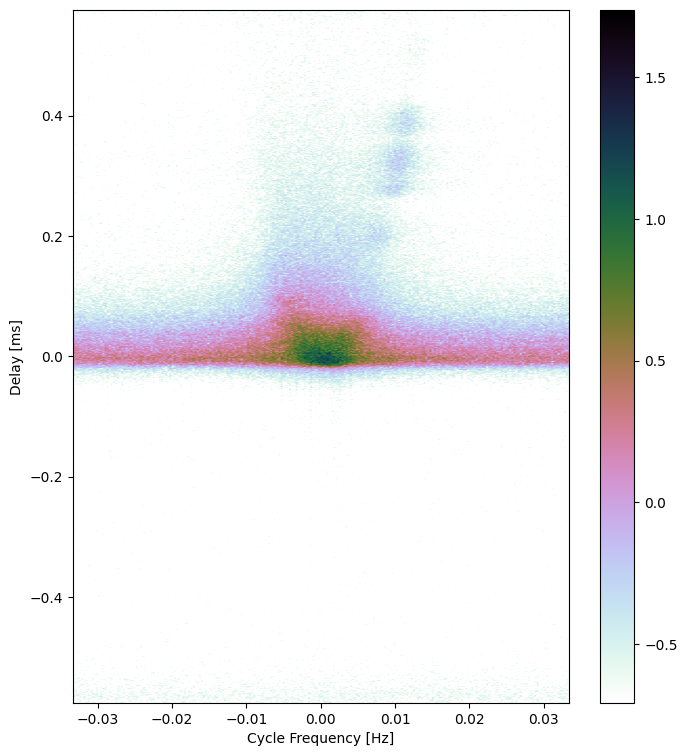

In [15]:
plot_Doppler_vs_delay(coarse_h_time_freq, dT, cfreq, bw)

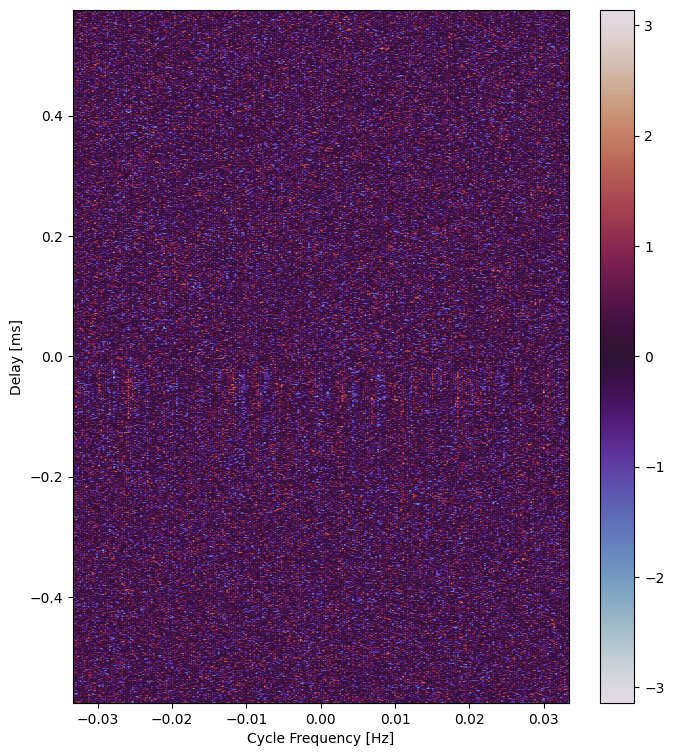

In [16]:
import matplotlib.colors as mcolors

# Define the color cycle
colors = ["blue", "red", "blue"]

# Create the colormap
cmap_name = "cyclic_colormap"
cyclic_cmap = mcolors.LinearSegmentedColormap.from_list(cmap_name, colors, N=256)

def plot_Doppler_vs_delay_phase (h_time_freq, dT, cfreq, bw):

    h_time_delay = freq2time(h_time_freq, axis=1)
    h_doppler_delay = time2freq(h_time_delay, axis=0)

    ntime, ntap = h_time_delay.shape

    delta_delay_mus = np.abs(1.0 / bw)
    max_delay_ms = delta_delay_mus * ntap * 0.5e-3
    max_Doppler_Hz = .5 / dT
    
    extent=[-max_Doppler_Hz, max_Doppler_Hz, -max_delay_ms, max_delay_ms]
    
    plotthis = np.angle(fftshift(h_doppler_delay))
    fig, ax = plt.subplots(figsize=(8, 9))

    ax.set_xlabel("Cycle Frequency [Hz]")
    ax.set_ylabel("Delay [ms]")
    img = ax.imshow(plotthis.T, aspect="auto", origin="lower", cmap='twilight', extent=extent)

    fig.colorbar(img)

plot_Doppler_vs_delay_phase(h_time_freq, dT, cfreq, bw)